# Tutorial 9: Capstone — your own pipeline, end to end

Estimated time: 45-60 minutes

## Prerequisites
PyMC backend installed (one of `py312_bayesmm_pymc`, `py312_bayesmm_sbi`, or the unified `py312_bayesmm` env). Tutorials 1, 4, and 5 ideally completed first — this capstone composes their lessons.

## Learning aims
- Primary package aim: **compose** what you learned. Build your *own* DOE, run it, fit a surrogate on the resulting sweep, evaluate the surrogate at new inputs you choose, and produce one figure + one paragraph that summarizes what your surrogate believes.
- Secondary aim: leave with concrete proof you can drive the framework end to end without copying notebook cells. The deliverable below is what you'd hand to another lab member.

## Success criteria
- you choose a custom DOE, run it, fit a surrogate, evaluate at new inputs, write a fill-in deliverable below, and another lab member can reproduce your output by running this notebook.


## Why this tutorial matters

Up to now, each tutorial has been one slice of the framework — validate / plan / run / fit / eval / build / sample, each demonstrated on a fixed example. Here you **compose** them. The point is not that you build something publishable in 45 minutes; the point is you can show another lab member you can drive the whole framework end to end without copy-paste, on inputs you chose yourself.

If the previous tutorials felt like "type these commands and see this output," this one is "now you decide what to type." The framework's value is exactly this composability: every step is the same spec → CLI → artifact contract whether you're running a 5-point toy sweep or coupling four real biological models.

(The natural next step beyond this capstone is **coupling**: T7 and T8 showed you what coupling looks like. The "real" version of T7-T8-T9 composed together at full scale on four biological models is `projects/tcr_signaling/` — see the closing pointer at the bottom of this notebook.)


## Pre-flight: check prior tutorial artifacts

This capstone builds on earlier tutorials. The cell below checks which artifacts exist so you know what to expect.

In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)


Repo root: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs


In [2]:
import json
from pathlib import Path

root = Path.cwd().resolve()
if not (root / "src").is_dir() and (root.parent / "src").is_dir():
    root = root.parent

checks = {
    "Tutorial specs": root / "tutorials" / "specs",
    "Run registry": root / "tmp" / "run_registry.json",
    "Surrogate registry": root / "tmp" / "surrogate_registry.json",
    "Metamodel registry": root / "tmp" / "meta_registry.json",
    "Metamodel samples registry": root / "tmp" / "metamodel_samples_registry.json",
}

print("Pre-flight artifact check:")
for label, p in checks.items():
    exists = p.exists()
    status = "FOUND" if exists else "MISSING (some steps may be skipped)"
    print(f"  {label}: {status}")

Pre-flight artifact check:
  Tutorial specs: FOUND
  Run registry: FOUND
  Surrogate registry: FOUND
  Metamodel registry: FOUND
  Metamodel samples registry: FOUND


## Step 1: Pick your DOE

You're going to build a *custom* DOE on the toy program. The cell below creates a temporary spec where you choose 5 grid points (you can edit `MY_GRID_A` and `MY_GRID_B` to whatever values you want, on the input box `[0, 2]²`). The framework then validates, plans, and runs it.

This is the muscle T1 / T4 built. The whole loop should take under 10 seconds.


In [3]:
import json

# === EDIT ME ===
# Pick 5 grid values for `a` and 5 for `b`. They'll be combined as the
# Cartesian product into a 5x5 = 25-point sweep.
# Try changing these and re-running — that's the point of "your" DOE.
MY_GRID_A = [0.1, 0.6, 1.1, 1.6, 1.9]
MY_GRID_B = [0.1, 0.6, 1.1, 1.6, 1.9]
# ===============

# Build a temporary spec by mutating the toy grid spec.
base_spec = json.loads((root / "tutorials/specs/model.toy.grid.json").read_text())
base_spec["model"]["name"] = "tutorial9_capstone_grid"
base_spec["design"]["grid"] = {"a": MY_GRID_A, "b": MY_GRID_B}
base_spec["storage"]["root"] = "tmp/tutorials/capstone_store"

capstone_spec_path = root / "tmp/tutorials/specs/capstone.grid.json"
capstone_spec_path.parent.mkdir(parents=True, exist_ok=True)
capstone_spec_path.write_text(json.dumps(base_spec, indent=2, sort_keys=True))
CAPSTONE_SPEC_REL = str(capstone_spec_path.relative_to(root))

print(f"Wrote: {capstone_spec_path}")
print(f"DOE: {len(MY_GRID_A)} a-values × {len(MY_GRID_B)} b-values = {len(MY_GRID_A) * len(MY_GRID_B)} points")

# Validate, plan, run.
run_mm_cli("validate", CAPSTONE_SPEC_REL)
run_mm_cli("plan", CAPSTONE_SPEC_REL)
run_mm_cli("run", CAPSTONE_SPEC_REL)


Wrote: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs/tmp/tutorials/specs/capstone.grid.json
DOE: 5 a-values × 5 b-values = 25 points


$ bayesmm validate tmp/tutorials/specs/capstone.grid.json
Spec validation passed: model=tutorial9_capstone_grid, strategy=grid, adapter=python_cli_adapter_v1
$ bayesmm plan tmp/tutorials/specs/capstone.grid.json
Plan points: 25
Preview:
1: {'a': 0.1, 'b': 0.1}
2: {'a': 0.1, 'b': 0.6}
3: {'a': 0.1, 'b': 1.1}
4: {'a': 0.1, 'b': 1.6}
5: {'a': 0.1, 'b': 1.9}


$ bayesmm run tmp/tutorials/specs/capstone.grid.json
Running point 1/25: {'a': 0.1, 'b': 0.1}
Running point 2/25: {'a': 0.1, 'b': 0.6}
Running point 3/25: {'a': 0.1, 'b': 1.1}
Running point 4/25: {'a': 0.1, 'b': 1.6}
Running point 5/25: {'a': 0.1, 'b': 1.9}
Running point 6/25: {'a': 0.6, 'b': 0.1}
Running point 7/25: {'a': 0.6, 'b': 0.6}
Running point 8/25: {'a': 0.6, 'b': 1.1}
Running point 9/25: {'a': 0.6, 'b': 1.6}
Running point 10/25: {'a': 0.6, 'b': 1.9}
Running point 11/25: {'a': 1.1, 'b': 0.1}
Running point 12/25: {'a': 1.1, 'b': 0.6}
Running point 13/25: {'a': 1.1, 'b': 1.1}
Running point 14/25: {'a': 1.1, 'b': 1.6}
Running point 15/25: {'a': 1.1, 'b': 1.9}
Running point 16/25: {'a': 1.6, 'b': 0.1}
Running point 17/25: {'a': 1.6, 'b': 0.6}
Running point 18/25: {'a': 1.6, 'b': 1.1}
Running point 19/25: {'a': 1.6, 'b': 1.6}
Running point 20/25: {'a': 1.6, 'b': 1.9}
Running point 21/25: {'a': 1.9, 'b': 0.1}
Running point 22/25: {'a': 1.9, 'b': 0.6}
Running point 23/25: {'a': 1.9, 

0

## Step 2: Fit a PyMC surrogate on your sweep

The cell below builds a tutorial-9-specific surrogate spec that points its `dataset_ref.run_store_root` at the storage you just populated, then fits a PyMC GP surrogate on your DOE. This is the same surrogate machinery from T5; the only thing that's different is the dataset comes from *your* DOE.


In [4]:
import json

# Build a surrogate spec pointing at the capstone storage from Step 1.
base_surr = json.loads((root / "tutorials/specs/surrogate.toy.pymc_gp.json").read_text())
base_surr["name"] = "tutorial9_capstone_surrogate"
base_surr["dataset_ref"]["run_store_root"] = "tmp/tutorials/capstone_store"

capstone_surr_path = root / "tmp/tutorials/specs/capstone.surrogate.pymc_gp.json"
capstone_surr_path.write_text(json.dumps(base_surr, indent=2, sort_keys=True))
CAPSTONE_SURR_REL = str(capstone_surr_path.relative_to(root))

print(f"Wrote: {capstone_surr_path}")
print(f"  dataset_ref.run_store_root: {base_surr['dataset_ref']['run_store_root']}")

run_mm_cli("surrogate", "fit", CAPSTONE_SURR_REL)
run_mm_cli("surrogate", "list")


Wrote: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs/tmp/tutorials/specs/capstone.surrogate.pymc_gp.json
  dataset_ref.run_store_root: tmp/tutorials/capstone_store


$ bayesmm surrogate fit tmp/tutorials/specs/capstone.surrogate.pymc_gp.json
Surrogate artifact stored: artifact_id=8deb076218a54f1ea16affa271fdca25 path=tmp/surrogate_artifacts/8deb076218a54f1ea16affa271fdca25/artifact.json
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [beta, intercept, sigma]
Sampling 1 chain for 300 tune and 300 draw iterations (300 + 300 draws total) took 0 seconds.
$ bayesmm surrogate list
Surrogate artifacts: 35
- 061276af338347f1977fca0170286e27: tmp/surrogate_artifacts/061276af338347f1977fca0170286e27/artifact.json
- 0db1d39e0dbf40038ee8eb710fed6df4: tmp/surrogate_artifacts/0db1d39e0dbf40038ee8eb710fed6df4/artifact.json
- 1520ec6fc87b4e7eac7b54bed7ea12aa: tmp/surrogate_artifacts/1520ec6fc87b4e7eac7b54bed7ea12aa/artifact.json
- 1bb340491ce141eeb98859ccc1fe4d28: tmp/surrogate_artifacts/1bb340491ce141eeb98859ccc1fe4d28/artifact.json
- 1de7c11c7db24b8dac49fb68e8106a85: tmp/surrogate_artifacts/1de7c11c7db24b8dac49fb68e8106

0

## Step 3: Evaluate your surrogate at NEW points (the actual scientific value)

This is the payoff. A trained surrogate predicts at *any* input — including inputs you never ran the simulator at. Pick 4 query points NOT in your training grid. The surrogate returns a posterior predictive (mean + std) at each.

If your training grid covers the input box well, the surrogate's predictive widths will be small. If you queried outside the convex hull of your training points, widths will grow — that's the surrogate honestly admitting it doesn't know.


In [5]:
import json

# === EDIT ME ===
# Pick 4 query points that are NOT in your DOE grid. Try mixing some safely
# inside the box and some near or outside the corners.
QUERY_INPUTS = {
    "a": [0.35, 0.85, 1.45, 1.85],
    "b": [0.55, 1.25, 0.75, 1.15],
}
# ===============

run_mm_cli(
    "surrogate", "eval", CAPSTONE_SURR_REL,
    "--inputs", json.dumps(QUERY_INPUTS),
    "--n", "300",
)


$ bayesmm surrogate eval tmp/tutorials/specs/capstone.surrogate.pymc_gp.json --inputs {"a": [0.35, 0.85, 1.45, 1.85], "b": [0.55, 1.25, 0.75, 1.15]} --n 300
{
  "artifact_id": "8deb076218a54f1ea16affa271fdca25",
  "backend": "pymc_gp",
  "n": 300,
  "sample_shape": [
    4,
    300
  ],
  "samples_preview": [
    [
      0.8999999042174543,
      0.8999995945720659,
      0.9000004084349108,
      0.899999949641686,
      0.9000001136975962
    ],
    [
      2.100000044517883,
      2.1000004964286334,
      2.1000001434848428,
      2.0999999222054617,
      2.1000000188546313
    ],
    [
      2.2000001561576457,
      2.1999995512245674,
      2.200000055471251,
      2.1999995823602245,
      2.199999906006955
    ]
  ],
  "summary": {
    "mean": [
      0.8999999924484143,
      2.0999999978974966,
      2.199999996218964,
      2.9999999995970437
    ],
    "n": 4,
    "output_correlation": "diagonal",
    "posterior_draws": 300,
    "std": [
      2.377078963904612e-07,
     

0

## Step 4: Visualize what your surrogate believes

The plot below renders your training inputs (gray X), the analytical truth `y = a + b` (dotted line), and your surrogate's posterior-predictive mean ± std at the query points. Same shape as T5's augmented plot — but on YOUR data.


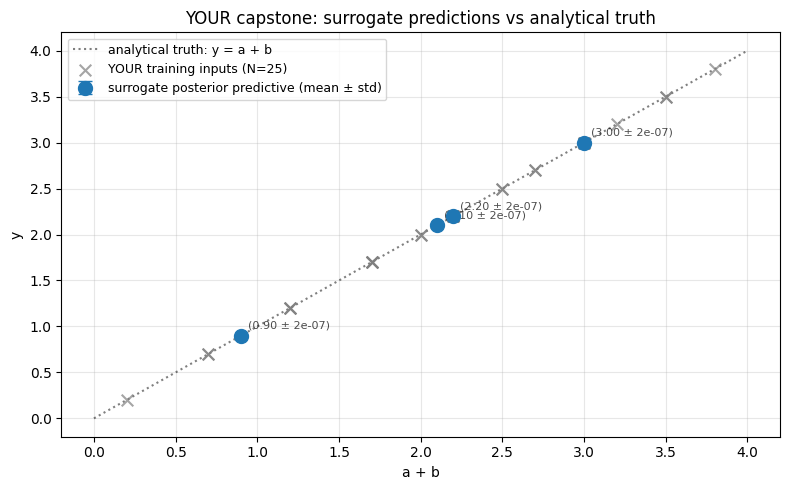


=== Capstone numeric summary ===
DOE size              : 25 training points
Query points          : 4
Predicted means       : [0.9, 2.1, 2.2, 3.0]
Analytical truth      : [0.9, 2.1, 2.2, 3.0]
Predictive std (each) : [2.38e-07, 2.36e-07, 2.37e-07, 2.37e-07]
Mean abs error vs truth: 0.0000


In [6]:
import csv
import json
import numpy as np
import matplotlib.pyplot as plt

from bayesian_metamodeling.spec import SurrogateSpec
from bayesian_metamodeling.surrogates import eval_surrogate

# Load and re-eval the capstone surrogate (cheap; prints structured result for your records).
spec = SurrogateSpec.model_validate(json.loads(capstone_surr_path.read_text()))
result = eval_surrogate(spec=spec, inputs_payload=QUERY_INPUTS, n=300)
mean = np.asarray(result["summary"]["mean"], dtype=float)
std = np.asarray(result["summary"].get("std", [0.0] * len(mean)), dtype=float)
query_x = np.asarray(QUERY_INPUTS["a"]) + np.asarray(QUERY_INPUTS["b"])

# Pull training observations from your sweep CSV.
sweep_csv = next(
    (root / "tmp/tutorials/capstone_store/sweeps").glob("*/sweep_rows.csv"),
    None,
)
train_a, train_b, train_y = [], [], []
if sweep_csv is not None:
    with open(sweep_csv) as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row.get("status") != "success":
                continue
            train_a.append(float(row["a"]))
            train_b.append(float(row["b"]))
            train_y.append(float(row.get("y__0", float(row["a"]) + float(row["b"]))))
train_a = np.asarray(train_a)
train_b = np.asarray(train_b)
train_y = np.asarray(train_y)
train_x = train_a + train_b

fig, ax = plt.subplots(figsize=(8, 5))
xx = np.linspace(0, 4, 100)
ax.plot(xx, xx, "k:", alpha=0.5, label="analytical truth: y = a + b")
ax.scatter(train_x, train_y, marker="x", s=70, c="tab:gray", alpha=0.7,
           label=f"YOUR training inputs (N={len(train_x)})", zorder=3)
ax.errorbar(query_x, mean, yerr=std, fmt="o", color="tab:blue",
            markersize=10, capsize=5,
            label="surrogate posterior predictive (mean ± std)", zorder=4)
for qx, m, s in zip(query_x, mean, std):
    ax.annotate(f"({m:.2f} ± {s:.0e})", xy=(qx, m), xytext=(5, 5),
                textcoords="offset points", fontsize=8, alpha=0.7)

ax.set_title("YOUR capstone: surrogate predictions vs analytical truth")
ax.set_xlabel("a + b")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print("\n=== Capstone numeric summary ===")
print(f"DOE size              : {len(train_x)} training points")
print(f"Query points          : {len(query_x)}")
print(f"Predicted means       : {[float(f'{m:.4f}') for m in mean]}")
print(f"Analytical truth      : {[float(f'{q:.4f}') for q in query_x]}")
print(f"Predictive std (each) : {[float(f'{s:.2e}') for s in std]}")
print(f"Mean abs error vs truth: {np.mean(np.abs(mean - query_x)):.4f}")


## Final deliverable (fill in this cell)

**Edit the markdown below.** Replace each `<placeholder>` with your actual values. The filled-in cell IS the deliverable — another lab member should be able to read it and reproduce your run.

---

### Capstone report

**Date**: `<YYYY-MM-DD>`
**Author**: `<your name>`

**1. DOE you chose** (edit Step 1 cell, then fill these in):

- `MY_GRID_A` = `<list>`
- `MY_GRID_B` = `<list>`
- Total training points: `<integer>`

**2. Surrogate fit** (look at the output of Step 2's `surrogate list`):

- Surrogate artifact id: `<artifact_id>`
- Backend: `pymc_gp`
- Run store root: `tmp/tutorials/capstone_store`

**3. Query points** (edit Step 3 cell, then fill these in):

- Query a-values: `<list>`
- Query b-values: `<list>`

**4. Result** (read off Step 4's numeric summary):

- Predicted means: `<list>`
- Analytical truth (`a + b`): `<list>`
- Mean absolute error: `<float>`
- Predictive std (typical): `<scientific notation>`

**5. Three-sentence interpretation**:

`<sentence 1: did the surrogate agree with analytical truth at your query points?>`
`<sentence 2: where were the predictive widths smallest / widest, and does that match where your training grid was densest?>`
`<sentence 3: what would you change about your DOE choice if you had to redo this with a model where the truth is unknown?>`

---

If another lab member can read this filled-in cell, run all cells of this notebook, and reproduce your numbers, **you passed**. The point isn't perfection; it's reproducibility.


## Where to go next: `projects/tcr_signaling/`

If you found this exercise interesting, the **real** version of it lives in `projects/tcr_signaling/` — a git submodule reproducing Neve-Oz, Sherman & Raveh, "Bayesian metamodeling of early T-cell antigen receptor signaling," *Frontiers in Immunology* 2024. That submodule applies the same workflow you just did to **four real biological models**:

- Membrane topography (IRM-derived tight-contact geometry)
- Kinetic segregation (CD45 spatial exclusion from tight contacts)
- Lck activity (radial decay from CD45 boundaries)
- TCR phosphorylation (Lck* phosphorylates TCR ITAMs)

The spec contracts and surrogate fits look exactly like what you just did — **with the biology you came to do**. The submodule's `README.md` walks the reproduction. Note: it has its own dependencies (CMake, a C++ toolchain, and a Metal-only GPU kernel for the kinetic-segregation model) — see the parent `README.md` "Optional case study" section for what to expect.

There's no Tutorial 10. If you reach this point and still want more, the answer is: read a `projects/tcr_signaling/specs/*.json` file. They're the same shape you've been editing.


## Optional appendix: toolchain quality gate

The cells below run the package's repository-level quality gate (`ruff` + the fast test suite). They are NOT part of the capstone — they're a confidence check that your environment is fully healthy. Useful if anything earlier surprised you, or before pushing changes upstream. Skip on a first read; come back if you'll edit framework code.


In [7]:
# Quality gate scoped to the metamodeling package (src/ + tests/).
# `check=False` so a failing test or warning doesn't stop the notebook —
# the optional appendix is meant to be inspectable, not blocking.
run_tool("ruff", "format", "--check", "src", "tests", check=False)
run_tool("ruff", "check", "src", "tests", check=False)
run_tool("pytest", "-q", "-m", "not slow", "tests", check=False)


$ ruff format --check src tests
91 files already formatted
$ ruff check src tests


All checks passed!
$ pytest -q -m not slow tests


.....................................................................s.s [ 26%]
.s...................................................................... [ 53%]
........................................................................ [ 80%]
..................................................F.                     [100%]
=================================== FAILURES ===================================
__________ test_tutorial_6_uses_portable_paths_and_pytest_invocation ___________

    def test_tutorial_6_uses_portable_paths_and_pytest_invocation():
        notebook_path = Path("tutorials/Tutorial_6.ipynb")
        text = _tutorial_source_text(notebook_path)
    
        assert "/Users/barak/Downloads/metamodeler_codex_scaffold_docs" not in text
>       assert "repo_root = cwd" in text
E       assert 'repo_root = cwd' in "# Tutorial 6: SBI Surrogate Learning (`sbi_npe`)\n\nEstimated time: 30-50 minutes\n\n## Prerequisites\n`torch` and `s... read.\nrun_tool('pytest', '-q', 'tests/test_surro

1

In [8]:
# Optional backend smoke checks (skipped cleanly if PyMC / SBI not installed).
run_tool("pytest", "-q", "tests/test_surrogate_backends.py", "-k",
         "pymc_gp_backend_fit_sample_and_logprob", check=False)
run_tool("pytest", "-q", "tests/test_surrogate_backends.py", "-k",
         "sbi_npe_backend_fit_sample_and_logprob", check=False)


$ pytest -q tests/test_surrogate_backends.py -k pymc_gp_backend_fit_sample_and_logprob


.                                                                        [100%]
$ pytest -q tests/test_surrogate_backends.py -k sbi_npe_backend_fit_sample_and_logprob


.                                                                        [100%]


0